In [1]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
import os
import datetime
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


2024-11-28 09:44:10.723757: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
## load the dataset
data= pd.read_csv("data/default_of_credit_card.csv")
data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [4]:
# Check for unnecessary columns
print(data.columns)

# Ensure all data types are correctly formatted
data = data.apply(pd.to_numeric, errors='ignore')  # Convert to numeric where applicable

# Separate features and target
X = data.drop(columns=['default_payment_next_month'])  # Features
y = data['default_payment_next_month']  # Target

# Check the updated dataset structure
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")


Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default_payment_next_month'],
      dtype='object')
Features shape: (30000, 24)
Target shape: (30000,)


/var/folders/1v/rgbrl8yj10q39dr4l_r0c8800000gn/T/ipykernel_79209/2423434314.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(pd.to_numeric, errors='ignore')  # Convert to numeric where applicable


In [5]:
data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [6]:
# Convert all columns to numeric if possible
data = data.apply(pd.to_numeric, errors='coerce')  # Replace non-numeric values with NaN
print(data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [7]:
# Check for Class Imbalance
print(y.value_counts(normalize=True))

default_payment_next_month
0    0.7788
1    0.2212
Name: proportion, dtype: float64



## **Cleaning the Dataset**

- Remove any rows with invalid labels (e.g., `default_payment_next_month`).

- Ensure all columns are numeric where applicable.

In [8]:
# Remove invalid labels
data = data[data['default_payment_next_month'].isin([0, 1])]  # Keep only rows with labels 0 or 1
y = data['default_payment_next_month']  # Update target variable
X = data.drop(columns=['default_payment_next_month'])  # Update features dataset

In [9]:
# Convert all columns to numeric (if not already)
X = X.apply(pd.to_numeric, errors='coerce')

# Verify the changes
print(f"New Target Distribution:\n{y.value_counts(normalize=True)}\n")
print(f"Dataset Info After Cleaning:\n{X.info()}\n")

New Target Distribution:
default_payment_next_month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000

## **Handle Missing Values**
- Check for missing values introduced during the cleaning process and impute or remove them as needed.

In [10]:

# Check for missing values
missing_values = X.isnull().sum()
print(f"Missing Values:\n{missing_values[missing_values > 0]}\n")

# Fill missing values with the median (or another strategy)
X.fillna(X.median(), inplace=True)


Missing Values:
Series([], dtype: int64)




### **Class Balancing**

- Apply oversampling or SMOTE to handle the class imbalance.

In [11]:


#### Oversampling:

from imblearn.over_sampling import RandomOverSampler

# Oversample the minority class
oversampler = RandomOverSampler(random_state=42)
X_balanced, y_balanced = oversampler.fit_resample(X, y)

# Verify the new distribution
print(f"New Target Distribution After Oversampling:\n{y_balanced.value_counts(normalize=True)}\n")


New Target Distribution After Oversampling:
default_payment_next_month
1    0.5
0    0.5
Name: proportion, dtype: float64



# **ANN IMPLEMENTATION**

## **Feature Scaling:**
- Scale the features to standardize their ranges. This is particularly important for algorithms like ANN, which are sensitive to feature scaling.



In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_balanced_scaled = scaler.fit_transform(X_balanced)

**Splitting the Data:**
   - Split the balanced dataset into training and testing sets.

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
       X_balanced_scaled, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
   )

**Setup Callbacks**

To improve your model training, let's incorporate callbacks like EarlyStopping to avoid overfitting and TensorBoard for visualizing the training process in real-time.

1. EarlyStopping Callback
EarlyStopping monitors a specific metric (like validation loss) and stops the training when it no longer improves, preventing overfitting.

2. TensorBoard Callback
TensorBoard allows you to visualize training metrics like loss, accuracy, and others during the model training process.

In [14]:

# Create directories for TensorBoard logs
log_dir = "logs/fit" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
os.makedirs(log_dir, exist_ok=True)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',               # Monitor the validation loss
    patience=5,                        # Stop after 5 epochs with no improvement
    restore_best_weights=True,         # Restore best model weights
    verbose=1
)

# TensorBoard callback
tensorboard_callback = TensorBoard(
    log_dir=log_dir,                   # Path for logs
    histogram_freq=1,                   # Log histograms every epoch
    write_graph=True,                   # Log the model graph
    write_images=True                   # Log weights as images
)


In [15]:
## Load Tensorboard Extension
%load_ext tensorboard

In [16]:
%tensorboard --logdir=logs/fit

**Building the Artificial Neural Network (ANN):**

- Design and train an ANN to classify the default payment cases.

In [17]:
# Build the ANN
model = Sequential([
      Dense(64, activation='relu', input_dim=X_train.shape[1]),
      Dropout(0.3),
      Dense(32, activation='relu'),
      Dropout(0.3),
      Dense(1, activation='sigmoid')  # Output layer for binary classification
   ])


model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                1600      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 3713 (14.50 KB)
Trainable params: 3713 (14.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


The model summary shows the architecture of the neural network you've built. Here's a breakdown of each layer:

1. **Dense Layer (64 units)**:
   - The first layer has 64 neurons.
   - It connects to all the neurons from the input layer, with a total of 1536 parameters (input features × units + bias term).

2. **Dropout Layer (rate=0.2)**:
   - This dropout layer will randomly "drop" 20% of the neurons during training to prevent overfitting.

3. **Dense Layer (32 units)**:
   - The second dense layer has 32 neurons, and it has 2080 parameters (input features from the previous layer × units + bias term).

4. **Dropout Layer (rate=0.2)**:
   - Another dropout layer that will drop 20% of neurons.

5. **Dense Layer (1 unit)**:
   - The final dense layer has a single neuron, as this is a binary classification task.
   - It has 33 parameters (32 units from the previous layer + 1 bias term).


In [18]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the ANN with callbacks
history = model.fit(
    X_train, y_train,
    epochs=50,               # Number of epochs
    batch_size=32,           # Batch size
    validation_split=0.2,    # Use 20% of the data for validation
    callbacks=[early_stopping, tensorboard_callback],  # Add callbacks here
    verbose=1
)

Epoch 1/50
935/935 [==============================] - 4s 3ms/step - loss: 0.6145 - accuracy: 0.6683 - val_loss: 0.5814 - val_accuracy: 0.7032
Epoch 2/50
935/935 [==============================] - 3s 3ms/step - loss: 0.5900 - accuracy: 0.6900 - val_loss: 0.5725 - val_accuracy: 0.7030
Epoch 3/50
935/935 [==============================] - 3s 3ms/step - loss: 0.5782 - accuracy: 0.7000 - val_loss: 0.5657 - val_accuracy: 0.7086
Epoch 4/50
935/935 [==============================] - 3s 3ms/step - loss: 0.5743 - accuracy: 0.7019 - val_loss: 0.5625 - val_accuracy: 0.7138
Epoch 5/50
935/935 [==============================] - 3s 3ms/step - loss: 0.5697 - accuracy: 0.7046 - val_loss: 0.5577 - val_accuracy: 0.7149
Epoch 6/50
935/935 [==============================] - 2s 3ms/step - loss: 0.5652 - accuracy: 0.7057 - val_loss: 0.5569 - val_accuracy: 0.7177
Epoch 7/50
935/935 [==============================] - 2s 3ms/step - loss: 0.5622 - accuracy: 0.7078 - val_loss: 0.5594 - val_accuracy: 0.7178
Epoch 

**TensorBoard Visualization**

After training, you can launch TensorBoard to view the training and validation metrics from the terminal


"tensorboard --logdir=logs/fit"


**Save the model**

In [19]:
# Save the model
model.save('my_model.keras')  # Save in Keras format



**Evaluate the Model:**

- Assess the performance of your ANN on the test data.

In [20]:



# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
 



Test Accuracy: 0.7169


**Plot Metrics:**
- Visualize the training process (e.g., loss and accuracy curves).




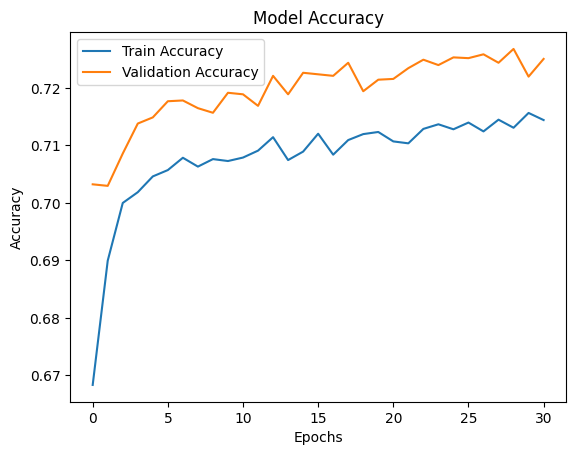

In [21]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()


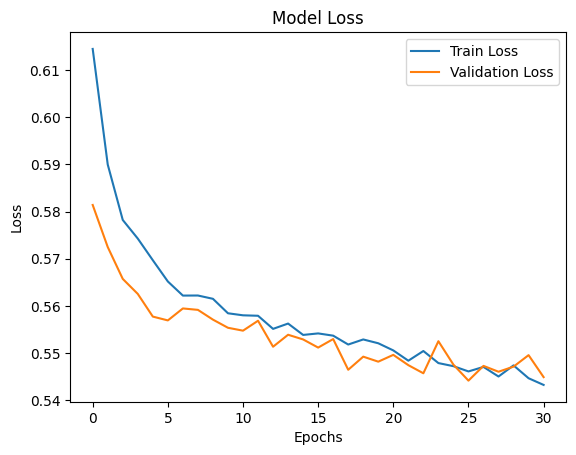

In [22]:
# Loss Plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

**Load and compile the model for future use**

In [23]:
# Load the saved model
model = load_model('my_model.keras')

# Manually compile the model if needed
model.compile(optimizer=Adam(learning_rate=0.001), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])



**Test the /predict endpoint by submitting sample data in JSON format. Here's an example of the input:**

{
    "LIMIT_BAL": 100000,

    "SEX": 2,

    "EDUCATION": 2,

    "MARRIAGE": 1,

    "AGE": 25,

    "PAY_0": 0,

    "PAY_2": 0,

    "PAY_3": 0,

    "PAY_4": 0,

    "PAY_5": 0,

    "PAY_6": 0,

    "BILL_AMT1": 50000,

    "BILL_AMT2": 48000,

    "BILL_AMT3": 47000,

    "BILL_AMT4": 46000,

    "BILL_AMT5": 45000,

    "BILL_AMT6": 44000,

    "PAY_AMT1": 10000,

    "PAY_AMT2": 12000,

    "PAY_AMT3": 15000,

    "PAY_AMT4": 13000,

    "PAY_AMT5": 11000,
    
    "PAY_AMT6": 10000
}
